In [9]:
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [10]:
active_test_scene_names = """5ZKStnWn8Zo
ARNzJeq3xxb
fzynW3qQPVF
gxdoqLR6rwA
gYvKGZ5eRqb
jtcxE69GiFV
pa4otMbVnkk
q9vSo1VnCiC
UwV83HsGsw3
Vt2qJdWjCF2
wc2JMjhGNzB
yqstnuAEVhm"""

# Split the data into a list of strings
active_test_scene_names = active_test_scene_names.split('\n')

In [11]:
test_scene_episode_counts = """
2023-10-11 16:53:30, INFO: Sampled 19 from 5ZKStnWn8Zo
2023-10-11 16:53:30, INFO: Sampled 10 from ARNzJeq3xxb
2023-10-11 16:53:31, INFO: Sampled 5 from UwV83HsGsw3
2023-10-11 16:53:31, INFO: Sampled 6 from Vt2qJdWjCF2
2023-10-11 16:53:31, INFO: Sampled 390 from fzynW3qQPVF
2023-10-11 16:53:31, INFO: Sampled 38 from gYvKGZ5eRqb
2023-10-11 16:53:31, INFO: Sampled 449 from gxdoqLR6rwA
2023-10-11 16:53:31, INFO: Sampled 4 from jtcxE69GiFV
2023-10-11 16:53:31, INFO: Sampled 34 from pa4otMbVnkk
2023-10-11 16:53:31, INFO: Sampled 17 from q9vSo1VnCiC
2023-10-11 16:53:31, INFO: Sampled 26 from wc2JMjhGNzB
2023-10-11 16:53:31, INFO: Sampled 2 from yqstnuAEVhm
"""

# Split the data into lines
lines = test_scene_episode_counts.strip().split('\n')

# Create a dictionary to store the mappings
test_scene_episode_counts_dict = {}

# Iterate through each line and extract the number sampled and the string
for line in lines:
    parts = line.split('from ')
    if len(parts) == 2:
        number_sampled = int(parts[0].split()[-1].strip())
        string_after_from = parts[1].strip()
        test_scene_episode_counts_dict[string_after_from] = number_sampled

# Print the resulting dictionary
print(test_scene_episode_counts_dict)

{'5ZKStnWn8Zo': 19, 'ARNzJeq3xxb': 10, 'UwV83HsGsw3': 5, 'Vt2qJdWjCF2': 6, 'fzynW3qQPVF': 390, 'gYvKGZ5eRqb': 38, 'gxdoqLR6rwA': 449, 'jtcxE69GiFV': 4, 'pa4otMbVnkk': 34, 'q9vSo1VnCiC': 17, 'wc2JMjhGNzB': 26, 'yqstnuAEVhm': 2}


In [12]:
dir_path = "/vision/asomaya1/active-rir/runs_eval/fs_rir"

with open(os.path.join(dir_path, "unseen_eval_364datapoints_metrics.pkl"), "rb") as f:
    metric_data = pickle.load(f)

with open(os.path.join(dir_path, "unseen_eval_364datapoints_sceneNames.pkl"), "rb") as f:
    scene_names = pickle.load(f)

with open("/vision/asomaya1/active-rir/data/metadata/scene_sizes.json", "rb") as f:
    scene_to_room_size = json.load(f)

In [13]:
# Calculate test set statistics
test_set_statistics = {}
for metric_name, metric_values in metric_data.items():
    mean = np.mean(metric_values)
    median = np.median(metric_values)
    std = np.std(metric_values)
    test_set_statistics[metric_name] = {
        'mean': mean,
        'median': median,
        'std': std
    }

scene_statistics = {}
# Iterate through unique scene names in your_scene_names
for scene_name in set(scene_names):
    if scene_name in active_test_scene_names:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name][:test_scene_episode_counts_dict[scene_name]]
    else:
        scene_indices = [i for i, name in enumerate(scene_names) if name == scene_name]
    room_size = scene_to_room_size.get(scene_name, None)  # Get the room size, if available
    num_episodes = len(scene_indices)
    
    if room_size is not None:
        scene_metric_values = {}
        
        # Calculate statistics for each metric
        for metric_name, metric_values in metric_data.items():
            scene_metric_values[metric_name] = {
                'mean': np.mean([metric_values[i] for i in scene_indices]),
                'median': np.median([metric_values[i] for i in scene_indices]),
                'std': np.std([metric_values[i] for i in scene_indices]),
            }
        
        # Store the scene statistics in the scene_statistics dictionary
        scene_statistics[scene_name] = {
            'num_episodes': num_episodes,
            'room_size': room_size,
            'metrics': scene_metric_values
        }

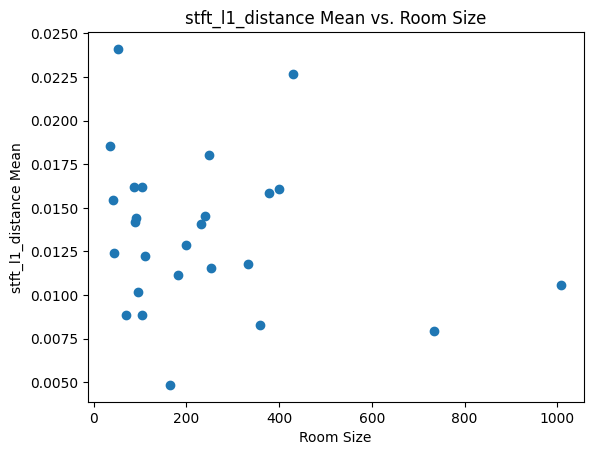

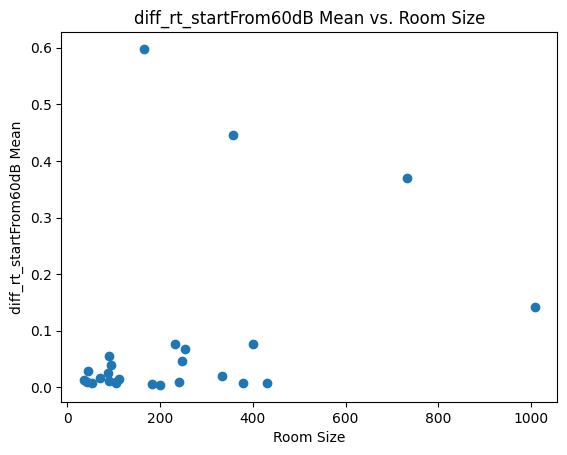

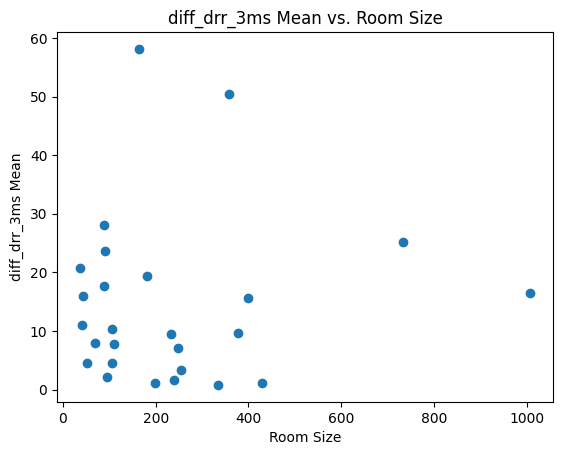

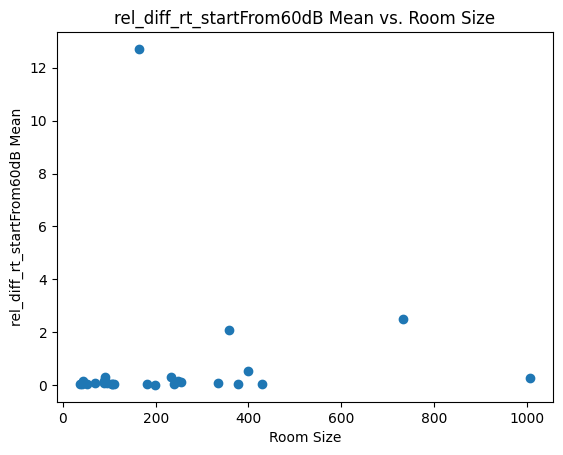

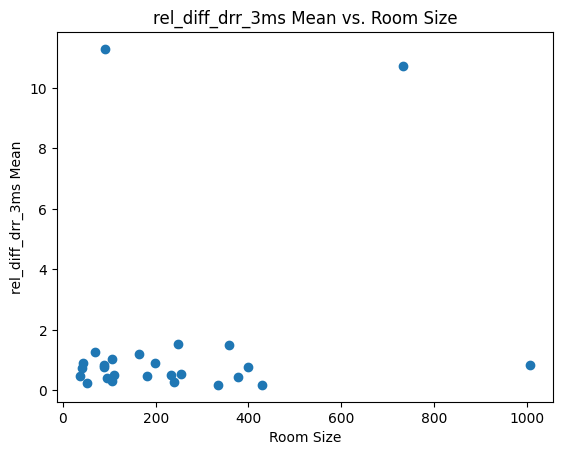

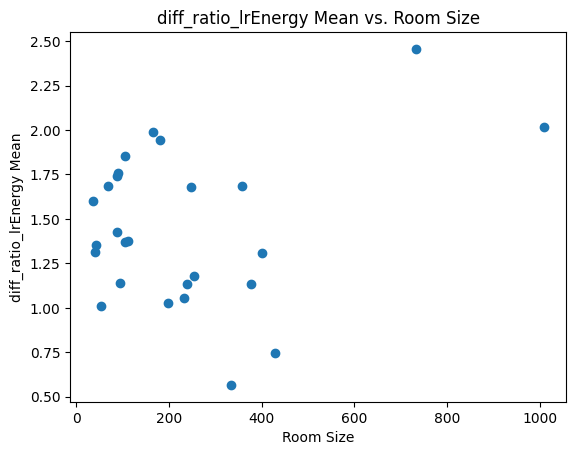

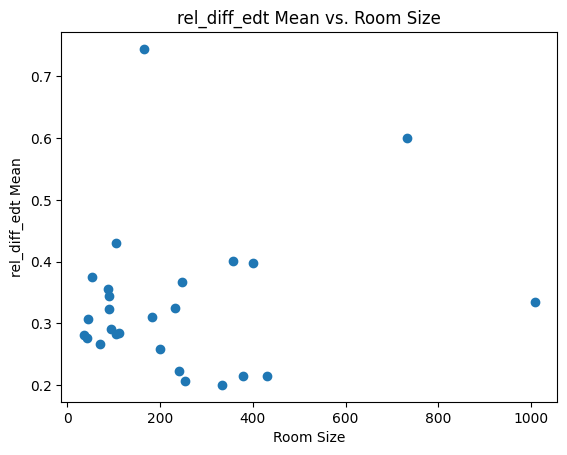

In [14]:
# Extract metric means and room sizes from scene statistics
metric_means = {metric_name: [] for metric_name in metric_data.keys()}
room_sizes = []

for scene_name, scene_data in scene_statistics.items():
    room_size = scene_data['room_size']
    room_sizes.append(room_size)
    
    for metric_name, metric_stats in scene_data['metrics'].items():
        metric_mean = metric_stats['mean']
        metric_means[metric_name].append(metric_mean)

# Create a bar plot for each metric
for metric_name, mean_values in metric_means.items():
    plt.figure()
    plt.scatter(room_sizes, mean_values)
    plt.xlabel('Room Size')
    plt.ylabel(metric_name + ' Mean')
    plt.title(metric_name + ' Mean vs. Room Size')
    plt.show()

In [15]:
scenes_to_eval = active_test_scene_names
#scenes_to_eval = list(set(scene_names)) #eval all scenes
drrs = []
metric_type = "median" #options: mean, median, std
for scene in scenes_to_eval:
    print(scene + " ({} episodes):".format(scene_statistics[scene]['num_episodes']))
    for metric in scene_statistics[scene]['metrics']:
        print(metric+":", scene_statistics[scene]['metrics'][metric][metric_type])
    print()

5ZKStnWn8Zo (19 episodes):
stft_l1_distance: 0.011268259957432747
diff_rt_startFrom60dB: 0.02109374999999998
diff_drr_3ms: 0.8249428584050778
rel_diff_rt_startFrom60dB: 0.08243723938051795
rel_diff_drr_3ms: 0.15408583991819869
diff_ratio_lrEnergy: 0.5343501137614983
rel_diff_edt: 0.12908841044434258

ARNzJeq3xxb (10 episodes):
stft_l1_distance: 0.013299642130732536
diff_rt_startFrom60dB: 0.004515624999999995
diff_drr_3ms: 1.140166405808353
rel_diff_rt_startFrom60dB: 0.008643037815423192
rel_diff_drr_3ms: 0.6257714308628528
diff_ratio_lrEnergy: 1.001026341539832
rel_diff_edt: 0.2237694265928472

fzynW3qQPVF (390 episodes):
stft_l1_distance: 0.005711749428883195
diff_rt_startFrom60dB: 0.26998437499999994
diff_drr_3ms: 12.851810962843734
rel_diff_rt_startFrom60dB: 0.585520161212995
rel_diff_drr_3ms: 0.5688718502950851
diff_ratio_lrEnergy: 1.8150433468314342
rel_diff_edt: 0.3295787503338167

gxdoqLR6rwA (449 episodes):
stft_l1_distance: 0.00970067735761404
diff_rt_startFrom60dB: 0.02803125

In [16]:
#Compute mean metrics for across scenes as ActiveRIR test set
mean_metrics = {}

for scene in scenes_to_eval:
    key = scene
    value = scene_statistics[key]
    metrics = value['metrics']
    for metric, metric_data in metrics.items():
        if metric not in mean_metrics:
            mean_metrics[metric] = []
        mean_metrics[metric].append(metric_data['mean'])

# Calculate the mean for each metric across all dictionaries
for metric, values in mean_metrics.items():
    if metric_type == "mean":
        mean_metrics[metric] = np.sum(values) / len(values)
    elif metric_type == "median":
        mean_metrics[metric] = np.median(values) 
    else:
        mean_metrics[metric] = np.std(values)

mean_metrics

{'stft_l1_distance': 0.011370465310143404,
 'diff_rt_startFrom60dB': 0.014388774671052625,
 'diff_drr_3ms': 6.493912019454026,
 'rel_diff_rt_startFrom60dB': 0.05883274574442658,
 'rel_diff_drr_3ms': 0.4527704641822219,
 'diff_ratio_lrEnergy': 1.1584259965001245,
 'rel_diff_edt': 0.274300298880875}